* IMPORT NECESSARY LIBRARIES

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import sklearn 
from sklearn import metrics 
from services import outliers, num_isnull

%matplotlib inline

* Getting the dataset from UCI

In [3]:
from ucimlrepo import fetch_ucirepo 
  

heart_disease = fetch_ucirepo(id=45) 
  

X = heart_disease.data.features 
y = heart_disease.data.targets 
  
print(heart_disease.variables) 


        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2              

In [4]:
df = heart_disease.data.original

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
df = heart_disease.data.original


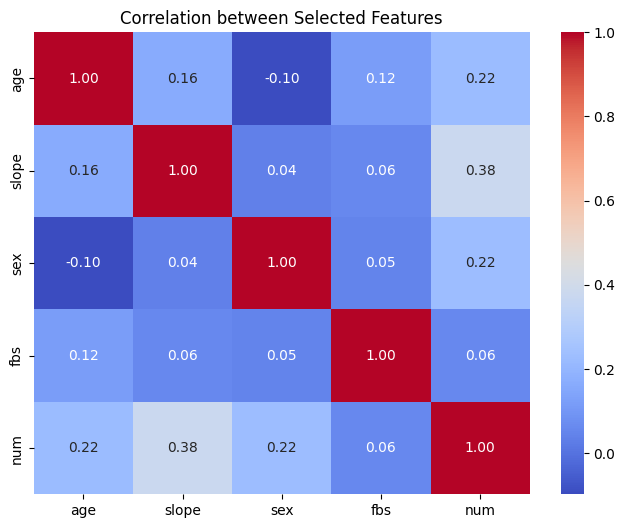

In [6]:
selected_features = ['age', 'slope', 'sex', 'fbs', 'num']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

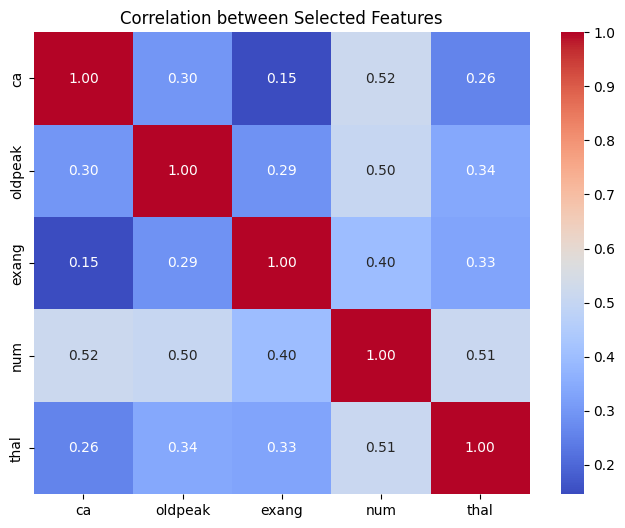

In [7]:
selected_features = ['ca', 'oldpeak', 'exang', 'num' , 'thal']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f") 


plt.title('Correlation between Selected Features')
plt.show()

* so the fretures our model will depend on is (slope , ca , oldpeak , thal)

In [8]:

print(num_isnull(df))

# as null values are small numbers of row so i chosse to drop them (C = 4 , THAL = 2 )

df.dropna(inplace=True)


print(num_isnull(df))

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [9]:
df = outliers(df , 'chol')
df = outliers (df , 'thalach')
df = outliers(df , 'trestbps')

Number of outliers in chol column was 5
Number of outliers in thalach column was 1
Number of outliers in trestbps column was 9
